In [1]:
%load_ext autoreload

from dotenv import load_dotenv

# Load environment variables from .env file
load_dotenv("../.env")

True

In [35]:
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rasterio
from omegaconf import OmegaConf
from sklearn.metrics import balanced_accuracy_score, f1_score

from estuary.model.config import EstuaryConfig
from estuary.model.data import create_splits
from estuary.util.img import false_color

In [141]:
SAVE_DIR = Path("/Users/kyledorman/data/estuary/display/paper_figures_2_class")
SAVE_DIR.mkdir(exist_ok=True, parents=True)

In [3]:
runs = []
for pth in Path("/Users/kyledorman/data/results/estuary/train/").glob("20260309*"):
    config_pth = pth / "conf_full.yaml"
    if not config_pth.exists():
        continue
    conf: EstuaryConfig = OmegaConf.load(config_pth)
    if conf.split_method != "crossval":
        continue
    runs.append((pth, conf))
len(runs)

6

In [4]:
run_results = [None] * len(runs)
run_regions = [None] * len(runs)

for pth, conf in runs:
    idx = conf.cv_index
    assert idx is not None

    preds = pd.read_csv(pth / "train_preds.csv")
    preds = preds[preds.y_true >= 0]

    _, _, df_test = create_splits(conf)

    test_regions = df_test.region.unique().tolist()
    run_regions[idx] = test_regions

    test_preds = preds[preds.region.isin(test_regions)]
    train_val_preds = preds[~preds.region.isin(test_regions)]

    run_results[idx] = (train_val_preds, test_preds)

Some label classes will be ignored {'unsure'}
Some label classes will be ignored {'unsure'}
Some label classes will be ignored {'unsure'}
Some label classes will be ignored {'unsure'}
Some label classes will be ignored {'unsure'}
Some label classes will be ignored {'unsure'}


In [90]:
dfs = []


def calc_f1(rdf):
    return f1_score(rdf.y_true, rdf.y_pred, labels=[0, 1], zero_division=1)


def calc_p_open(rdf):
    return rdf.y_true.mean()


def entropy_row(P):
    P = np.vstack([P, 1 - P]).T
    P = np.clip(P, 1e-6, 1)
    return -(P * np.log(P)).sum(axis=1)


def calc_entropy(rdf):
    return entropy_row(rdf.p_closed.to_numpy()).mean()


def calc_acc(rdf):
    return balanced_accuracy_score(rdf.y_true, rdf.y_pred)


for idx, (train_val_preds, test_preds) in enumerate(run_results):
    for name, tdf in [("train_val", train_val_preds), ("test", test_preds)]:
        f1 = tdf.groupby("region").apply(calc_f1, include_groups=False).rename("f1")
        p_open = tdf.groupby("region").apply(calc_p_open, include_groups=False).rename("p_open")
        entropy = tdf.groupby("region").apply(calc_entropy, include_groups=False).rename("entropy")

        fdf = pd.concat([f1, p_open, entropy], axis=1).reset_index()
        fdf["p_min"] = np.minimum(fdf.p_open, 1 - fdf.p_open).rename("p_min")

        fdf["cv_index"] = idx
        fdf["dataset"] = name
        dfs.append(fdf)
        # acc = tdf.groupby("region").apply(calc_acc, include_groups=False).rename("acc")

        # fdf = pd.merge(f1, acc, left_index=True, right_index=True, how='inner')

df = pd.concat(dfs, ignore_index=True)

df.head()

,region,f1,p_open,entropy,p_min,cv_index,dataset
0,11,0.996540,0.923077,0.011525,0.076923,0,train_val
1,14,0.991379,0.798611,0.008870,0.201389,0,train_val
2,15,0.996337,0.894737,0.005530,0.105263,0,train_val
3,16,0.952381,0.066667,0.010643,0.066667,0,train_val
4,17,1.000000,0.185714,0.018297,0.185714,0,train_val


In [204]:
base_preds = pd.read_csv(
    "/Users/kyledorman/data/results/estuary/train/20260305-095554/train_preds.csv"
)
base_preds = base_preds[base_preds.y_true >= 0].copy()

base_f1 = base_preds.groupby("region").apply(calc_f1, include_groups=False).rename("f1")

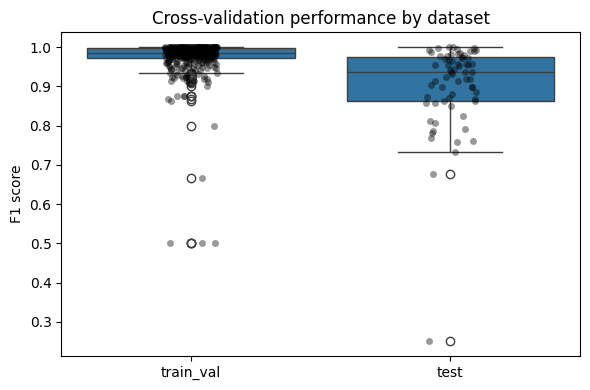

In [91]:
import seaborn as sns

plt.figure(figsize=(6, 4))

sns.boxplot(data=df, x="dataset", y="f1", order=["train_val", "test"])

sns.stripplot(data=df, x="dataset", y="f1", order=["train_val", "test"], color="black", alpha=0.4)

plt.ylabel("F1 score")
plt.xlabel("")
plt.title("Cross-validation performance by dataset")

plt.tight_layout()
plt.show()

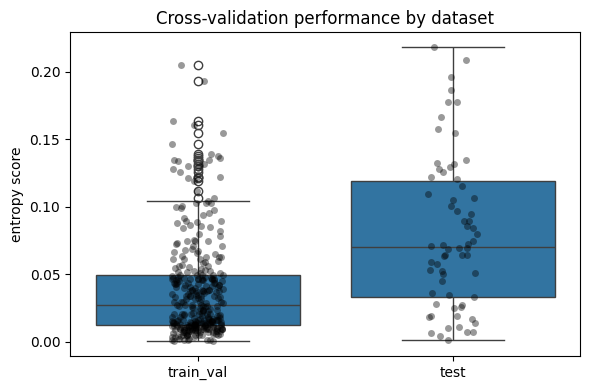

In [92]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 4))

sns.boxplot(data=df, x="dataset", y="entropy", order=["train_val", "test"])

sns.stripplot(
    data=df, x="dataset", y="entropy", order=["train_val", "test"], color="black", alpha=0.4
)

plt.ylabel("entropy score")
plt.xlabel("")
plt.title("Cross-validation performance by dataset")

plt.tight_layout()
plt.show()

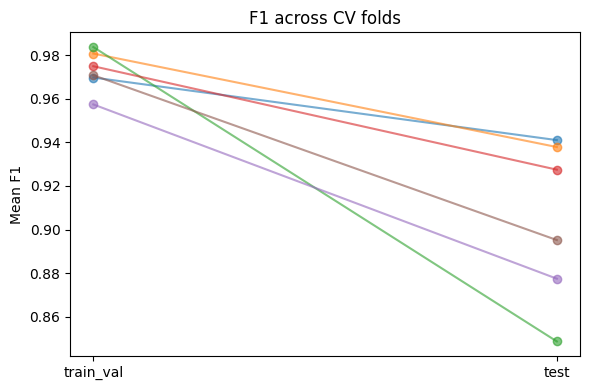

In [8]:
pivot = df.groupby(["cv_index", "dataset"])["f1"].mean().unstack()

plt.figure(figsize=(6, 4))

for _, r in pivot.iterrows():
    plt.plot(["train_val", "test"], r[["train_val", "test"]], marker="o", alpha=0.6)

plt.ylabel("Mean F1")
plt.title("F1 across CV folds")

plt.tight_layout()
plt.show()

In [9]:
import pandas as pd

train_val = df[df.dataset == "train_val"].groupby("region")["f1"].mean()

test = df[df.dataset == "test"].set_index("region")["f1"]

comp = pd.concat([train_val.rename("train_val"), test.rename("test")], axis=1).dropna()

comp["gap"] = comp["train_val"] - comp["test"]

In [108]:
import pandas as pd

train_val = df[df.dataset == "train_val"].groupby("region")["entropy"].mean()

test = df[df.dataset == "test"].set_index("region")["entropy"]

comp_entropy = pd.concat([train_val.rename("train_val"), test.rename("test")], axis=1).dropna()

comp_entropy["entropy_gap"] = comp_entropy["train_val"] - comp_entropy["test"]

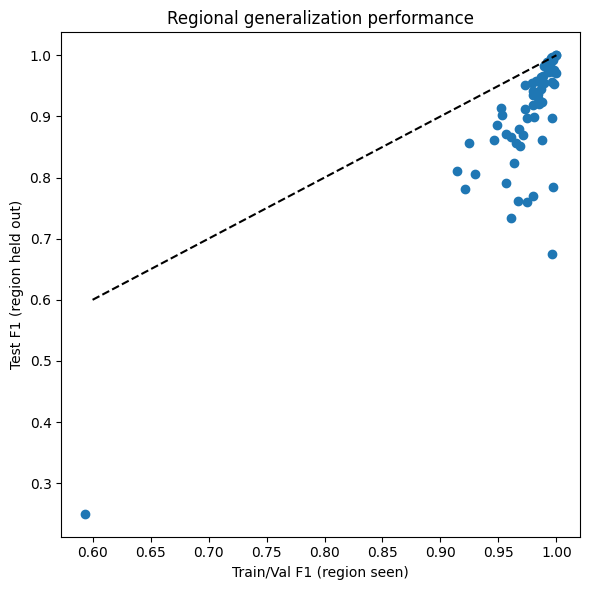

In [165]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 6))

plt.scatter(comp["train_val"], comp["test"])

plt.plot([0.6, 1], [0.6, 1], color="black", linestyle="--")

plt.xlabel("Train/Val F1 (region seen)")
plt.ylabel("Test F1 (region held out)")

plt.title("Regional generalization performance")

plt.tight_layout()
plt.show()

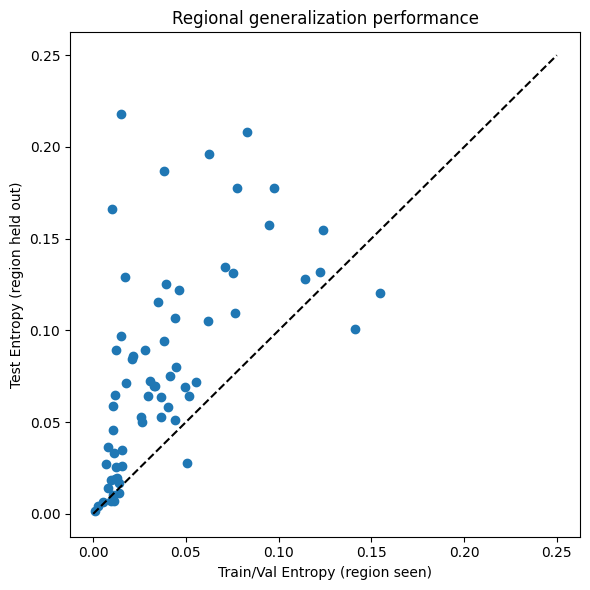

In [110]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 6))

plt.scatter(comp_entropy["train_val"], comp_entropy["test"])

plt.plot([0, 0.25], [0, 0.25], color="black", linestyle="--")

plt.xlabel("Train/Val Entropy (region seen)")
plt.ylabel("Test Entropy (region held out)")

plt.title("Regional generalization performance")

plt.tight_layout()
plt.show()

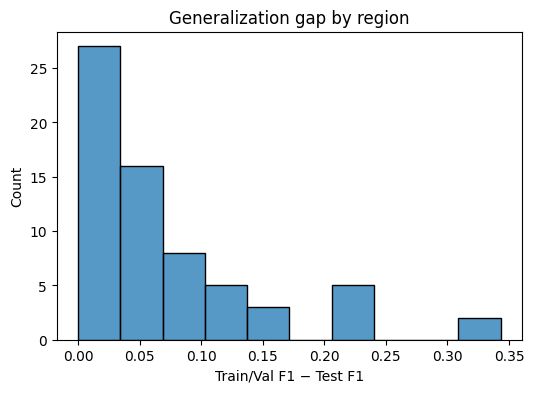

In [111]:
import seaborn as sns

plt.figure(figsize=(6, 4))

sns.histplot(comp["gap"], bins=10)

plt.xlabel("Train/Val F1 − Test F1")
plt.title("Generalization gap by region")

plt.show()

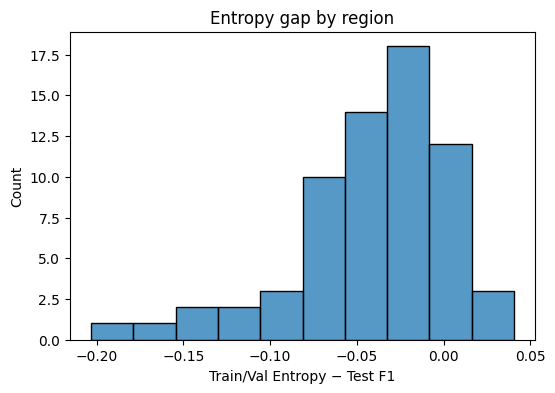

In [112]:
import seaborn as sns

plt.figure(figsize=(6, 4))

sns.histplot(comp_entropy["entropy_gap"], bins=10)

plt.xlabel("Train/Val Entropy − Test F1")
plt.title("Entropy gap by region")

plt.show()

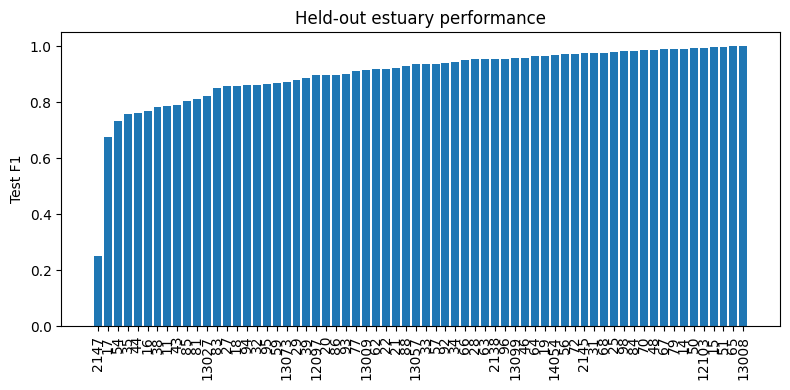

In [12]:
comp_sorted = comp.sort_values("test")

plt.figure(figsize=(8, 4))

plt.bar(comp_sorted.index.astype(str), comp_sorted["test"])

plt.xticks(rotation=90)

plt.ylabel("Test F1")
plt.title("Held-out estuary performance")

plt.tight_layout()
plt.show()

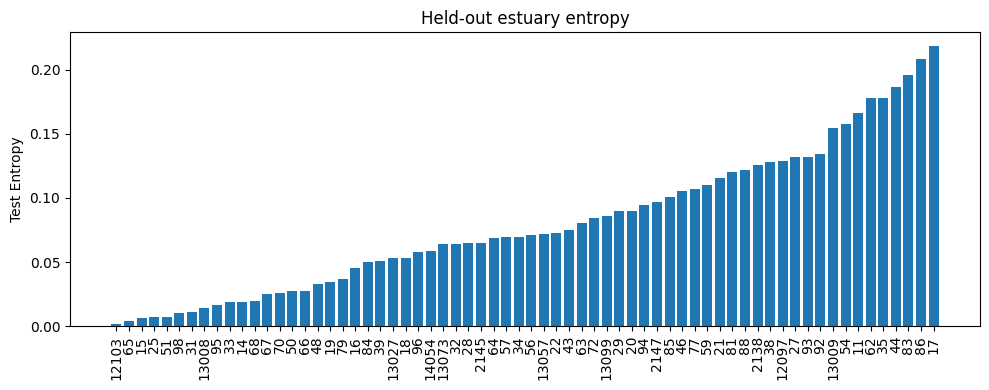

In [116]:
comp_sorted_entropy = comp_entropy.sort_values("test")

plt.figure(figsize=(10, 4))

plt.bar(comp_sorted_entropy.index.astype(str), comp_sorted_entropy["test"])

plt.xticks(rotation=90)

plt.ylabel("Test Entropy")
plt.title("Held-out estuary entropy")

plt.tight_layout()
plt.show()

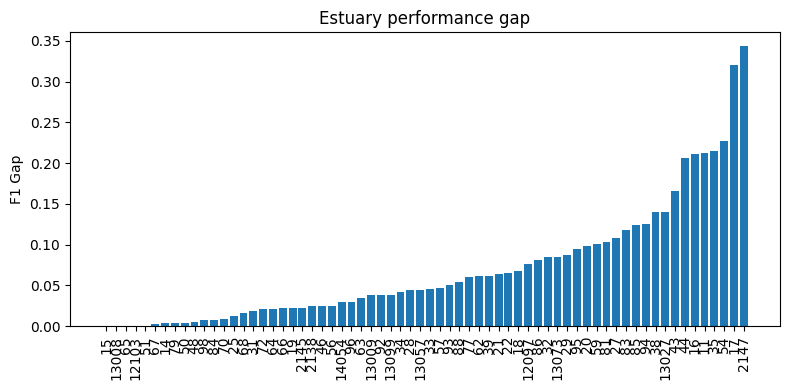

In [13]:
comp_sorted = comp.sort_values("gap")

plt.figure(figsize=(8, 4))

plt.bar(comp_sorted.index.astype(str), comp_sorted["gap"])

plt.xticks(rotation=90)

plt.ylabel("F1 Gap")
plt.title("Estuary performance gap")

plt.tight_layout()
plt.show()

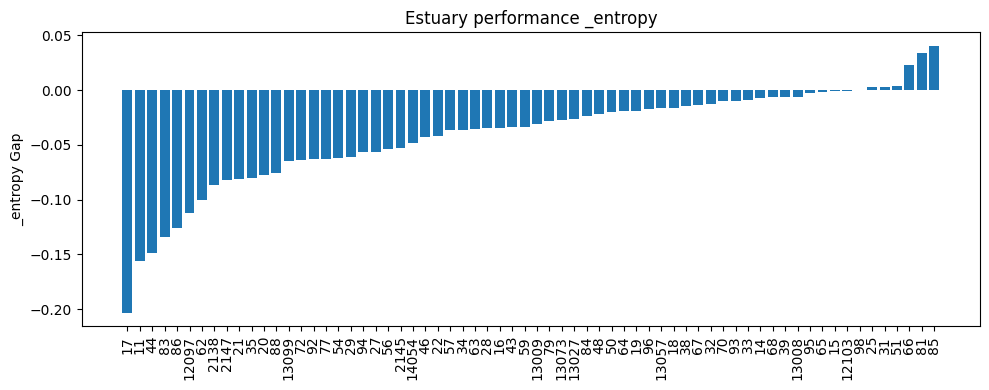

In [119]:
comp_sorted_entropy = comp_entropy.sort_values("entropy_gap")

plt.figure(figsize=(10, 4))

plt.bar(comp_sorted_entropy.index.astype(str), comp_sorted_entropy["entropy_gap"])

plt.xticks(rotation=90)

plt.ylabel("_entropy Gap")
plt.title("Estuary performance _entropy")

plt.tight_layout()
plt.show()

In [14]:
outliers = comp.sort_values("gap", ascending=False)

outliers.head(10)

,train_val,test,gap
region,,,
2147,0.593333,0.250000,0.343333
17,0.996078,0.675325,0.320754
54,0.960499,0.733333,0.227165
35,0.974223,0.759358,0.214865
11,0.997227,0.785124,0.212103
16,0.979950,0.769231,0.210719
44,0.967114,0.760870,0.206244
43,0.956718,0.790698,0.166020
13027,0.963137,0.823529,0.139608


In [24]:
good = comp.sort_values("gap")

good.head(10)

,train_val,test,gap
region,,,
15,0.996337,0.996337,0.000000e+00
13008,1.000000,1.000000,0.000000e+00
65,1.000000,1.000000,0.000000e+00
12103,0.995025,0.995025,1.110223e-16
51,0.997651,0.997067,5.830602e-04
67,0.991656,0.989583,2.072426e-03
14,0.994827,0.991379,3.448082e-03
79,0.993146,0.989619,3.526600e-03
50,0.996947,0.992481,4.465362e-03


<Axes: >

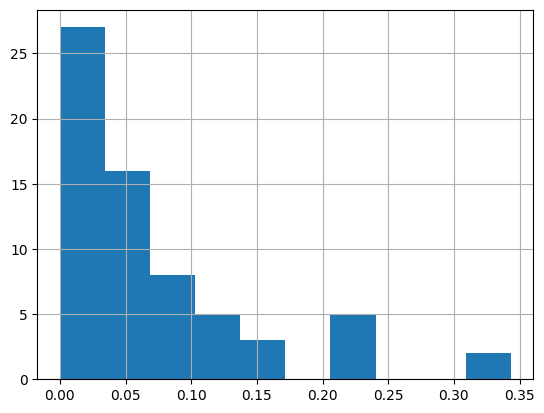

In [158]:
comp["gap"].hist()

In [16]:
comp["gap"].describe()

count    66.000000
mean      0.070572
std       0.075578
min       0.000000
25%       0.020673
50%       0.045214
75%       0.097406
max       0.343333
Name: gap, dtype: float64

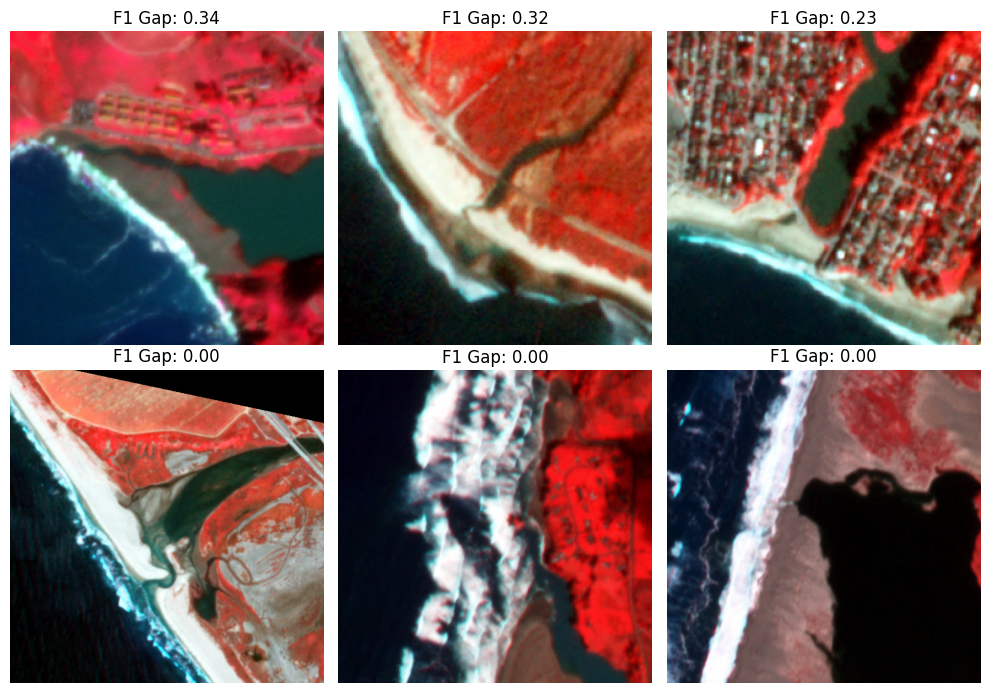

In [170]:
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(10, 7))

for ax, (region, gap_df) in zip(axes[0].flatten(), outliers.head(3).iterrows()):
    pth = preds[(preds.region == region) & (preds.y_true == 1)].source_tif.iloc[0]

    with rasterio.open(pth) as src:
        data = src.read().astype(np.float32)
        nodata = src.read(1, masked=True).mask
        img = false_color(data, nodata)

    ax.axis("off")
    ax.imshow(img)
    ax.set_title(f"F1 Gap: {gap_df.gap.item():.2f}")

for ax, (region, gap_df) in zip(axes[1].flatten(), good.head(3).iterrows()):
    pth = preds[(preds.region == region) & (preds.y_true == 1)].source_tif.iloc[0]

    with rasterio.open(pth) as src:
        data = src.read().astype(np.float32)
        nodata = src.read(1, masked=True).mask
        img = false_color(data, nodata)

    ax.axis("off")
    ax.imshow(img)
    ax.set_title(f"F1 Gap: {gap_df.gap.item():.2f}")

fig.tight_layout()
fig.savefig(SAVE_DIR / "example_low_high_f1_gap.png", dpi=300)
plt.show()

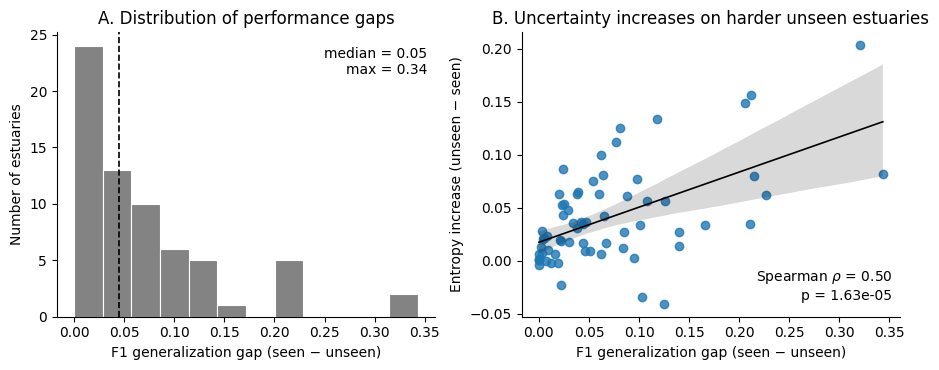

In [178]:
from scipy.stats import spearmanr

gap = comp["gap"].dropna()

df = (
    pd.merge(comp_entropy, comp, left_index=True, right_index=True)
    .rename(columns={"gap": "f1_gap"})
    .copy()
)
df["entropy_gap"] *= -1

rho, p = spearmanr(df["f1_gap"], df["entropy_gap"])

fig, axes = plt.subplots(1, 2, figsize=(9.2, 3.8))

# Panel A
sns.histplot(
    gap,
    bins=12,
    color="0.35",
    edgecolor="white",
    linewidth=0.8,
    ax=axes[0],
)
axes[0].axvline(gap.median(), color="black", linestyle="--", linewidth=1.2)
axes[0].set_xlabel("F1 generalization gap (seen − unseen)")
axes[0].set_ylabel("Number of estuaries")
axes[0].set_title("A. Distribution of performance gaps")
axes[0].spines["top"].set_visible(False)
axes[0].spines["right"].set_visible(False)
axes[0].text(
    0.98,
    0.95,
    f"median = {gap.median():.02f}\nmax = {gap.max():.02f}",
    transform=axes[0].transAxes,
    ha="right",
    va="top",
)

# Panel B
sns.regplot(
    data=df,
    x="f1_gap",
    y="entropy_gap",
    scatter_kws={"s": 36, "alpha": 0.8},
    line_kws={"color": "black", "linewidth": 1.2},
    ci=95,
    ax=axes[1],
)
axes[1].set_xlabel("F1 generalization gap (seen − unseen)")
axes[1].set_ylabel("Entropy increase (unseen − seen)")
axes[1].set_title("B. Uncertainty increases on harder unseen estuaries")
axes[1].spines["top"].set_visible(False)
axes[1].spines["right"].set_visible(False)
axes[1].text(
    0.98,
    0.05,
    f"Spearman $\\rho$ = {rho:.2f}\np = {p:.3g}",
    transform=axes[1].transAxes,
    ha="right",
    va="bottom",
)

plt.tight_layout()
plt.savefig(SAVE_DIR / "gap_hist_scatter.png", dpi=300)
plt.show()

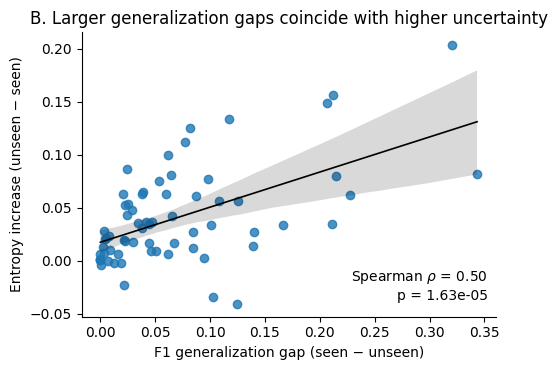

In [173]:
df = pd.merge(comp_entropy, comp, left_index=True, right_index=True).rename(
    columns={"gap": "f1_gap"}
)
df["entropy_gap"] *= -1

from scipy.stats import spearmanr

rho, p = spearmanr(df["f1_gap"], df["entropy_gap"])

fig, ax = plt.subplots(figsize=(5.2, 3.8))

sns.regplot(
    data=df,
    x="f1_gap",
    y="entropy_gap",
    scatter_kws={"s": 36, "alpha": 0.8},
    line_kws={"color": "black", "linewidth": 1.2},
    ci=95,
    ax=ax,
)

ax.set_xlabel("F1 generalization gap (seen − unseen)")
ax.set_ylabel("Entropy increase (unseen − seen)")
ax.set_title("B. Larger generalization gaps coincide with higher uncertainty")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.text(
    0.98,
    0.05,
    f"Spearman $\\rho$ = {rho:.2f}\np = {p:.3g}",
    transform=ax.transAxes,
    ha="right",
    va="bottom",
)

plt.tight_layout()
plt.savefig(SAVE_DIR / "gap_entropy_scatter.png", dpi=300)
plt.show()

In [26]:
comp[comp.train_val < 0.9]

,train_val,test,gap
region,,,
2147,0.593333,0.25,0.343333


In [129]:
display(preds[preds.region == 2147].y_true.value_counts())

preds[(preds.region == 2147) & (preds.y_true == 1)].year

y_true
0    127
1      3
Name: count, dtype: int64

11379    2024
11380    2025
11381    2025
Name: year, dtype: int64

In [36]:
BASE = Path("/Volumes/x10pro/estuary/")
gdf = gpd.read_file(BASE / "geos/ca_data_w_empa_pmep_usgs.geojson")
gdf = gdf[~gdf.skipped].copy()
gdf = gdf.set_index("Site code")
gdf.head(3)

,Site name,skipped,PMEP_EstuaryID,Estuary_Name,Data_Source,CMECS_Class,PMEP_Region,System_Order,Estuary_Hectares,Link,...,siteid,point_geom_lat,point_geom_long,pmep_pt_geom_lat,pmep_pt_geom_long,usgs_station_nm,usgs_site_no,usgs_site_latitude,usgs_site_longitude,geometry
Site code,,,,,,,,,,,,,,,,,,,,,
11,Los Penasquitos Lagoon,False,4056.0,Los Penasquitos Lagoon,PMEP,Lagoonal Estuary,Southern California Bight,299.0,95.475975,4056_Los Penasquitos Lagoon,...,SC-LPL,32.933,-117.260,32.931536,-117.256714,None,None,None,None,"POLYGON ((-117.25816 32.93218, -117.25817 32.9..."
18,Zuma Lagoon,False,4018.0,Zuma Canyon,PMEP,Lagoonal Estuary,Southern California Bight,262.0,1.779315,4018_Zuma Canyon,...,SC-ZUM,34.015,-118.821,34.014565,-118.820618,None,None,None,None,"POLYGON ((-118.81685 34.01177, -118.81699 34.0..."
21,Ventura River,False,4010.0,Ventura River,PMEP,Lagoonal Estuary,Southern California Bight,253.0,17.225009,4010_Ventura River,...,SC-VEN,34.276,-119.308,34.277309,-119.308329,None,None,None,None,"POLYGON ((-119.30473 34.27203, -119.3049 34.27..."


In [40]:
merged = pd.merge(
    comp,
    gdf[["Estuary_Name", "System_Order", "Estuary_Hectares"]],
    left_index=True,
    right_index=True,
)
merged.head()

,train_val,test,gap,Estuary_Name,System_Order,Estuary_Hectares
11,0.997227,0.785124,0.212103,Los Penasquitos Lagoon,299.0,95.475975
14,0.994827,0.991379,0.003448,San Luis Rey River,292.0,18.769904
15,0.996337,0.996337,0.000000,Santa Margarita Lagoon,290.0,184.223691
16,0.979950,0.769231,0.210719,Las Flores Creek,286.0,3.484179
17,0.996078,0.675325,0.320754,San Mateo Lagoon,283.0,4.324525


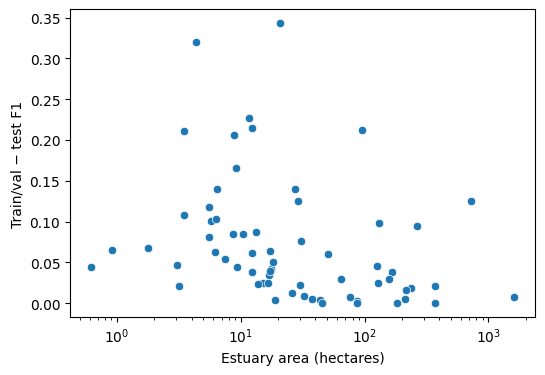

In [44]:
plt.figure(figsize=(6, 4))

sns.scatterplot(data=merged, x="Estuary_Hectares", y="gap")

plt.xscale("log")
plt.xlabel("Estuary area (hectares)")
plt.ylabel("Train/val − test F1")

plt.show()

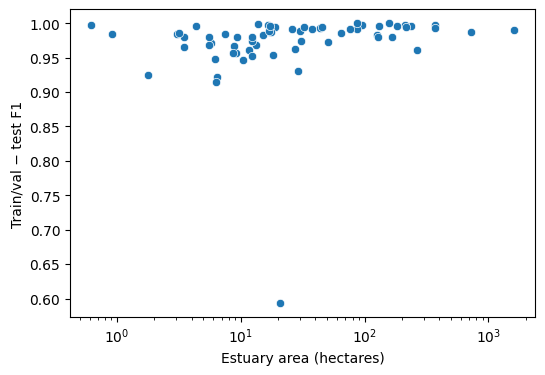

In [46]:
plt.figure(figsize=(6, 4))

sns.scatterplot(data=merged, x="Estuary_Hectares", y="train_val")

plt.xscale("log")
plt.xlabel("Estuary area (hectares)")
plt.ylabel("Train/val − test F1")

plt.show()

In [126]:
outliers_entropy = comp_entropy.sort_values("entropy_gap")

outliers_entropy.head(10)

,train_val,test,entropy_gap
region,,,
17,0.014976,0.218174,-0.203198
11,0.010231,0.166448,-0.156217
44,0.037965,0.186715,-0.148750
83,0.062320,0.196164,-0.133844
86,0.082825,0.208339,-0.125514
12097,0.017269,0.129134,-0.111865
62,0.077518,0.177640,-0.100122
2138,0.039313,0.125519,-0.086207
2147,0.015102,0.096842,-0.081740


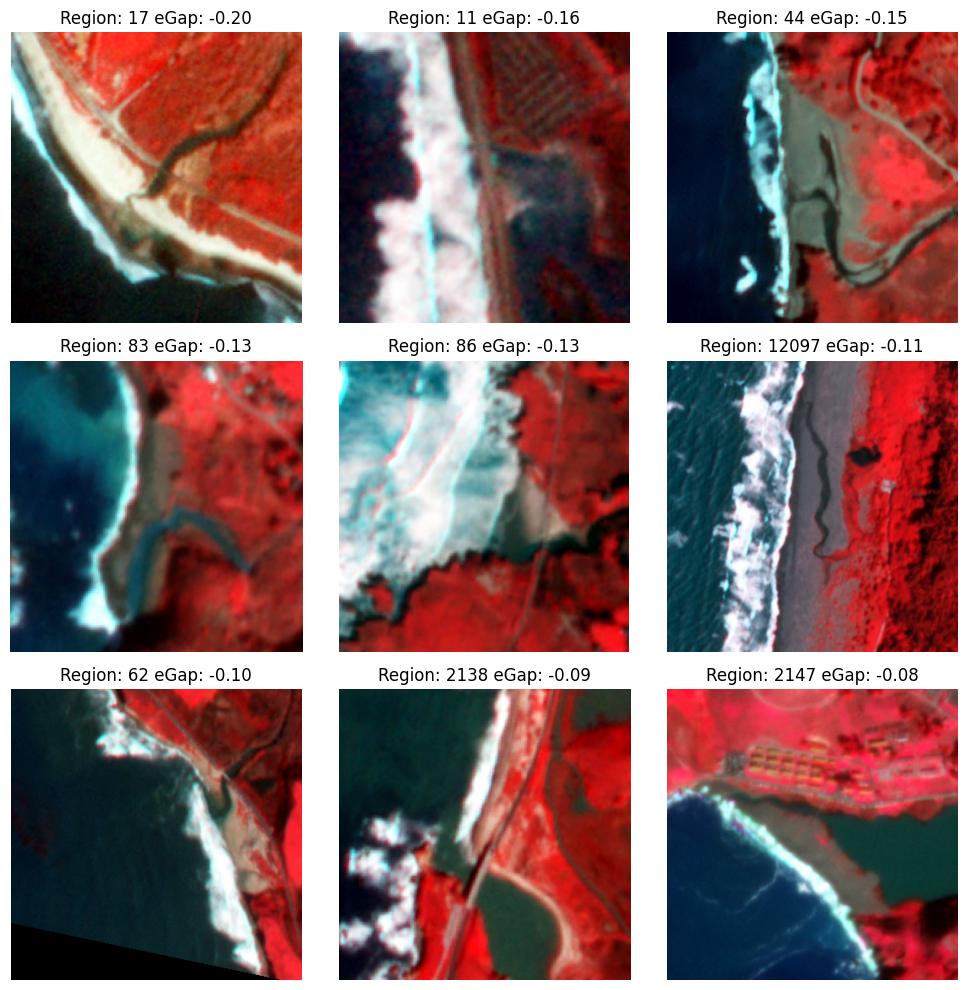

In [127]:
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(10, 10))

for ax, (region, gap_df) in zip(axes.flatten(), outliers_entropy.head(9).iterrows()):
    pth = preds[(preds.region == region) & (preds.y_true == 1)].source_tif.iloc[0]

    with rasterio.open(pth) as src:
        data = src.read().astype(np.float32)
        nodata = src.read(1, masked=True).mask
        img = false_color(data, nodata)

    ax.axis("off")
    ax.imshow(img)
    rdf = preds[preds.region == region]
    p_open = rdf.y_true.sum() / len(rdf)
    ax.set_title(f"Region: {region} eGap: {gap_df.entropy_gap.item():.2f}")

fig.tight_layout()
plt.show()

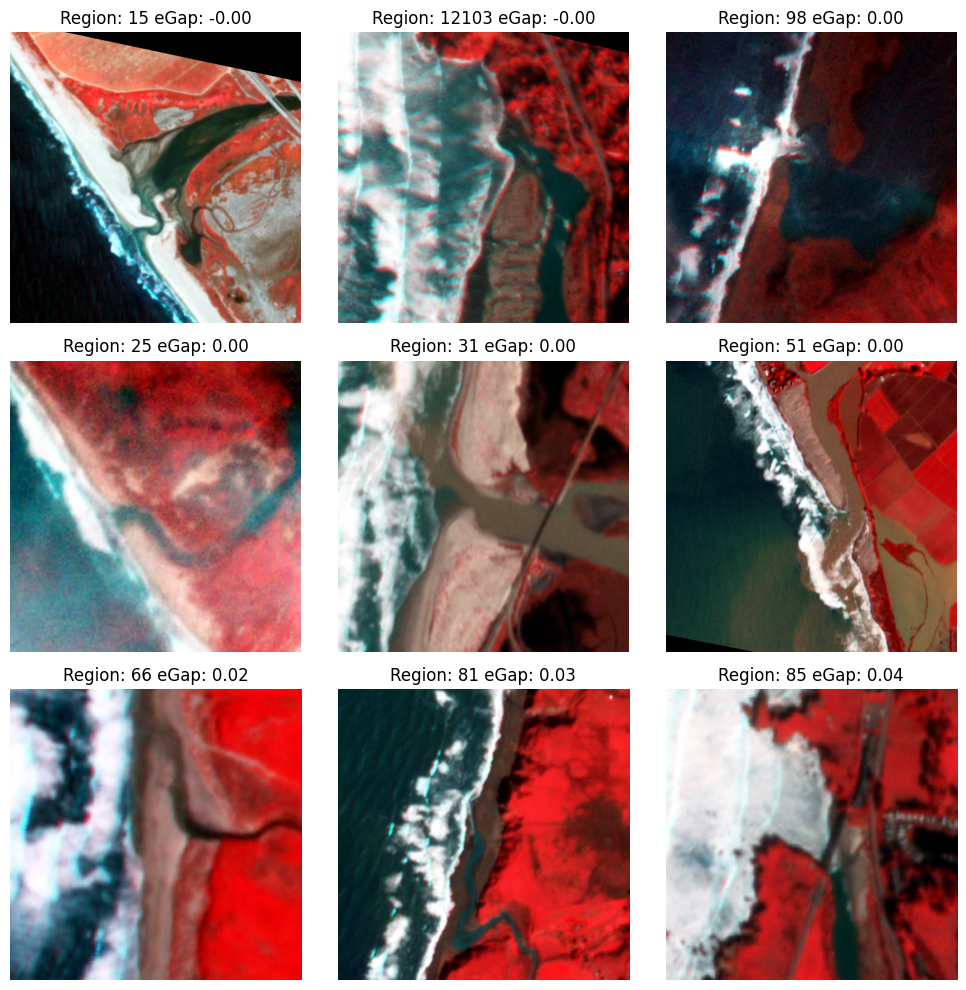

In [128]:
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(10, 10))

for ax, (region, gap_df) in zip(axes.flatten(), outliers_entropy.tail(9).iterrows()):
    pth = preds[(preds.region == region) & (preds.y_true == 1)].source_tif.iloc[0]

    with rasterio.open(pth) as src:
        data = src.read().astype(np.float32)
        nodata = src.read(1, masked=True).mask
        img = false_color(data, nodata)

    ax.axis("off")
    ax.imshow(img)
    rdf = preds[preds.region == region]
    p_open = rdf.y_true.sum() / len(rdf)
    ax.set_title(f"Region: {region} eGap: {gap_df.entropy_gap.item():.2f}")

fig.tight_layout()
plt.show()


Results Table

| Model           | Pretraining          | Bands   |    F1 |
|:----------------|:---------------------|:--------|------:|
| ConvNeXt-Tiny   | dinov3_lvd1689m      | NIR-R-G | 0.955 |
| ConvNeXt-Tiny   | dinov3_lvd1689m      | RGB     | 0.941 |
| ConvNeXt-Tiny   | ImageNet-22k         | NIR-R-G | 0.936 |
| ConvNeXtV2-Tiny | FCMAE & ImageNet-22k | NIR-R-G | 0.93  |
| ConvNeXtV2-Tiny | FCMAE                | NIR-R-G | 0.91  |


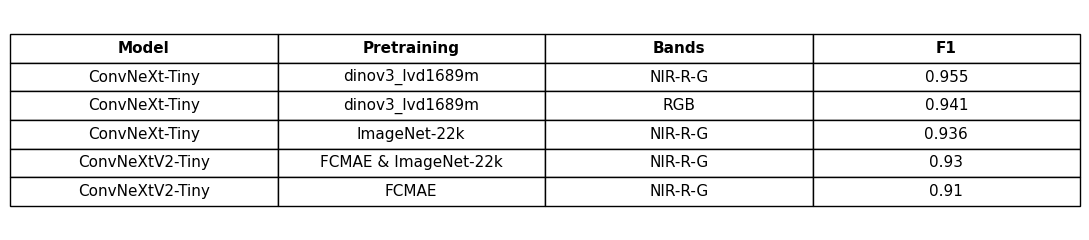

In [232]:
comp_params = []

main_preds = pd.read_csv(
    "/Users/kyledorman/data/results/estuary/train/20260305-095554/train_preds.csv"
)
main_preds = main_preds[(main_preds.year == 2025) & (main_preds.y_true >= 0)].copy()
main_preds["Model"] = "ConvNeXt-Tiny"
main_preds["Pretraining"] = "dinov3_lvd1689m"
main_preds["Bands"] = "NIR-R-G"
comp_params.append(main_preds)

pp = pd.read_csv("/Users/kyledorman/data/results/estuary/train/20260309-131506/train_preds.csv")
pp = pp[(pp.year == 2025) & (pp.y_true >= 0)].copy()
pp["Model"] = "ConvNeXt-Tiny"
pp["Pretraining"] = "ImageNet-22k"
pp["Bands"] = "NIR-R-G"
comp_params.append(pp)

pp = pd.read_csv("/Users/kyledorman/data/results/estuary/train/20260309-154804/train_preds.csv")
pp = pp[(pp.year == 2025) & (pp.y_true >= 0)].copy()
pp["Model"] = "ConvNeXtV2-Tiny"
pp["Pretraining"] = "FCMAE"
pp["Bands"] = "NIR-R-G"
comp_params.append(pp)

pp = pd.read_csv("/Users/kyledorman/data/results/estuary/train/20260309-165440/train_preds.csv")
pp = pp[(pp.year == 2025) & (pp.y_true >= 0)].copy()
pp["Model"] = "ConvNeXtV2-Tiny"
pp["Pretraining"] = "FCMAE & ImageNet-22k"
pp["Bands"] = "NIR-R-G"
comp_params.append(pp)

pp = pd.read_csv("/Users/kyledorman/data/results/estuary/train/20260311-095816/train_preds.csv")
pp = pp[(pp.year == 2025) & (pp.y_true >= 0)].copy()
pp["Model"] = "ConvNeXt-Tiny"
pp["Pretraining"] = "dinov3_lvd1689m"
pp["Bands"] = "RGB"
comp_params.append(pp)

run_params = pd.concat(comp_params)

table = (
    run_params.groupby(["Model", "Pretraining", "Bands"])
    .apply(calc_f1, include_groups=False)
    .round(3)
    .rename("F1")
    .sort_values(ascending=False)
    .to_frame()
    .reset_index()
)

print("\nResults Table\n")
print(table.to_markdown(index=False))

table.to_csv(SAVE_DIR / "pretrain_channels_compare.csv", index=False)

fig_h = 0.5 * len(table)

fig, ax = plt.subplots(figsize=(11, fig_h))
ax.axis("off")

tbl = ax.table(
    cellText=table.values,
    colLabels=table.columns,
    loc="center",
    cellLoc="center",
)

tbl.auto_set_font_size(False)
tbl.set_fontsize(11)
tbl.scale(1, 1.5)

for (row, col), cell in tbl.get_celld().items():
    if row == 0:
        cell.set_text_props(weight="bold")

fig.tight_layout()
fig.savefig(SAVE_DIR / "pretrain_channels_compare.png", dpi=300, bbox_inches="tight")
plt.show()


Results Table

| model                         |    F1 |
|:------------------------------|------:|
| connectivity classifier       | 0.858 |
| convnext_tiny.dinov3_lvd1689m | 0.838 |


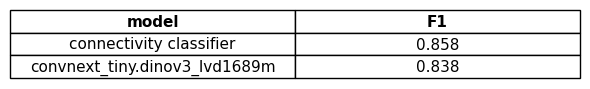

In [152]:
table = pd.DataFrame(
    [
        {"model": "connectivity classifier", "F1": 0.8585},
        {"model": "convnext_tiny.dinov3_lvd1689m", "F1": 0.8375},
    ]
).round(3)

print("\nResults Table\n")
print(table.to_markdown(index=False))

table.to_csv(SAVE_DIR / "low_quality_compare.csv", index=False)

fig_h = 0.5 * len(table)

fig, ax = plt.subplots(figsize=(6, fig_h))
ax.axis("off")

tbl = ax.table(
    cellText=table.values,
    colLabels=table.columns,
    loc="center",
    cellLoc="center",
)

tbl.auto_set_font_size(False)
tbl.set_fontsize(11)
tbl.scale(1, 1.5)

for (row, col), cell in tbl.get_celld().items():
    if row == 0:
        cell.set_text_props(weight="bold")

fig.tight_layout()
fig.savefig(SAVE_DIR / "low_quality_compare.png", dpi=300, bbox_inches="tight")
plt.show()

In [191]:
aaa = pd.read_csv("/Users/kyledorman/data/results/estuary/train/20260305-095554/train_preds.csv")
aaa = aaa[aaa.y_true >= 0]
test_df = aaa[aaa.year == 2025]
val_df = aaa[aaa.year == 2021]
train_df = aaa[(aaa.year != 2021) & (aaa.year != 2025)]


def p_open(gdf):
    return (gdf.y_true == 1).sum() / len(gdf)


def p_closed(gdf):
    return (gdf.y_true == 0).sum() / len(gdf)


datasets = []
for name, df in [("train", train_df), ("val", val_df), ("test", test_df)]:
    o = df.groupby("region").apply(p_open, include_groups=False).rename(f"{name}_p_open")
    c = df.groupby("region").apply(p_closed, include_groups=False).rename(f"{name}_p_closed")
    d = pd.merge(o, c, left_index=True, right_index=True)
    datasets.append(d)

df = pd.concat(datasets, axis=1)
df

,train_p_open,train_p_closed,val_p_open,val_p_closed,test_p_open,test_p_closed
region,,,,,,
11,0.918033,0.081967,0.882353,0.117647,1.000000,0.000000
14,0.824561,0.175439,0.600000,0.400000,0.800000,0.200000
15,0.886179,0.113821,1.000000,0.000000,0.846154,0.153846
16,0.084034,0.915966,0.000000,1.000000,0.000000,1.000000
17,0.234234,0.765766,0.000000,1.000000,0.000000,1.000000
...,...,...,...,...,...,...
13027,0.088235,0.911765,0.000000,1.000000,0.181818,0.818182
13057,0.635135,0.364865,0.454545,0.545455,0.583333,0.416667
13073,0.179487,0.820513,0.222222,0.777778,0.166667,0.833333


In [202]:
eps = 1e-6

df["open_diff"] = df["test_p_open"] - df["train_p_open"]
df["closed_diff"] = df["test_p_closed"] - df["train_p_closed"]

df["open_pct_change"] = (df["test_p_open"] - df["train_p_open"]) / (df["train_p_open"] + eps)
df["closed_pct_change"] = (df["test_p_closed"] - df["train_p_closed"]) / (
    df["train_p_closed"] + eps
)

df["open_abs_diff"] = df["open_diff"].abs()
df["closed_abs_diff"] = df["closed_diff"].abs()

df["distribution_shift"] = (df["train_p_open"] - df["test_p_open"]).abs()

display(df.sort_values("open_abs_diff", ascending=False).head(10))

display(df.sort_values("open_pct_change", ascending=False).head(10))

,train_p_open,train_p_closed,val_p_open,val_p_closed,test_p_open,test_p_closed,open_diff,closed_diff,open_pct_change,closed_pct_change,open_abs_diff,closed_abs_diff,distribution_shift
region,,,,,,,,,,,,,
34,0.431655,0.568345,0.176471,0.823529,0.875000,0.125000,0.443345,-0.443345,1.027081,-0.780062,0.443345,0.443345,0.443345
67,0.801802,0.198198,0.000000,1.000000,0.375000,0.625000,-0.426802,0.426802,-0.532303,2.153398,0.426802,0.426802,0.426802
68,0.553571,0.446429,0.000000,1.000000,0.250000,0.750000,-0.303571,0.303571,-0.548386,0.679998,0.303571,0.303571,0.303571
14054,0.897436,0.102564,0.888889,0.111111,0.600000,0.400000,-0.297436,0.297436,-0.331428,2.899972,0.297436,0.297436,0.297436
59,0.488372,0.511628,0.187500,0.812500,0.210526,0.789474,-0.277846,0.277846,-0.568921,0.543061,0.277846,0.277846,0.277846
13009,0.472222,0.527778,0.500000,0.500000,0.750000,0.250000,0.277778,-0.277778,0.588234,-0.526315,0.277778,0.277778,0.277778
62,0.648276,0.351724,0.733333,0.266667,0.913043,0.086957,0.264768,-0.264768,0.408418,-0.752769,0.264768,0.264768,0.264768
32,0.243697,0.756303,0.125000,0.875000,0.000000,1.000000,-0.243697,0.243697,-0.999996,0.322222,0.243697,0.243697,0.243697
17,0.234234,0.765766,0.000000,1.000000,0.000000,1.000000,-0.234234,0.234234,-0.999996,0.305882,0.234234,0.234234,0.234234


,train_p_open,train_p_closed,val_p_open,val_p_closed,test_p_open,test_p_closed,open_diff,closed_diff,open_pct_change,closed_pct_change,open_abs_diff,closed_abs_diff,distribution_shift
region,,,,,,,,,,,,,
2147,0.009901,0.990099,0.000000,1.000000,0.125000,0.875000,0.115099,-0.115099,11.623826,-0.116250,0.115099,0.115099,0.115099
65,0.016667,0.983333,0.000000,1.000000,0.052632,0.947368,0.035965,-0.035965,2.157765,-0.036574,0.035965,0.035965,0.035965
95,0.105263,0.894737,0.000000,1.000000,0.238095,0.761905,0.132832,-0.132832,1.261893,-0.148459,0.132832,0.132832,0.132832
25,0.159292,0.840708,0.066667,0.933333,0.357143,0.642857,0.197851,-0.197851,1.242056,-0.235338,0.197851,0.197851,0.197851
13027,0.088235,0.911765,0.000000,1.000000,0.181818,0.818182,0.093583,-0.093583,1.060594,-0.102639,0.093583,0.093583,0.093583
34,0.431655,0.568345,0.176471,0.823529,0.875000,0.125000,0.443345,-0.443345,1.027081,-0.780062,0.443345,0.443345,0.443345
13009,0.472222,0.527778,0.500000,0.500000,0.750000,0.250000,0.277778,-0.277778,0.588234,-0.526315,0.277778,0.277778,0.277778
85,0.449541,0.550459,0.142857,0.857143,0.666667,0.333333,0.217125,-0.217125,0.482992,-0.394444,0.217125,0.217125,0.217125
62,0.648276,0.351724,0.733333,0.266667,0.913043,0.086957,0.264768,-0.264768,0.408418,-0.752769,0.264768,0.264768,0.264768


In [203]:
df.distribution_shift.describe()

count    66.000000
mean      0.105789
std       0.101126
min       0.000000
25%       0.031336
50%       0.073428
75%       0.147236
max       0.443345
Name: distribution_shift, dtype: float64

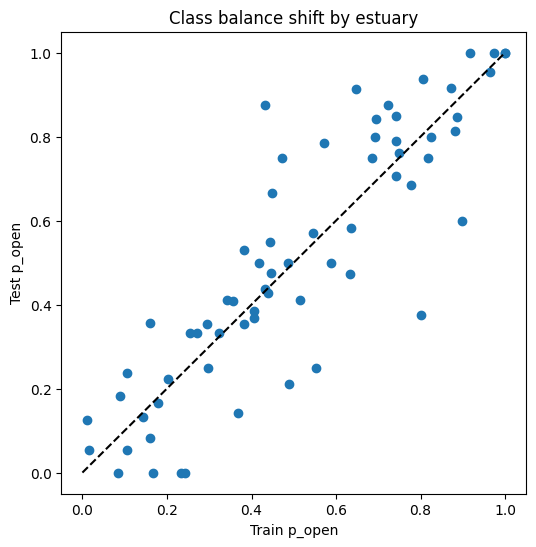

In [195]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 6))

plt.scatter(df["train_p_open"], df["test_p_open"])

plt.plot([0, 1], [0, 1], linestyle="--", color="black")

plt.xlabel("Train p_open")
plt.ylabel("Test p_open")

plt.title("Class balance shift by estuary")

plt.show()

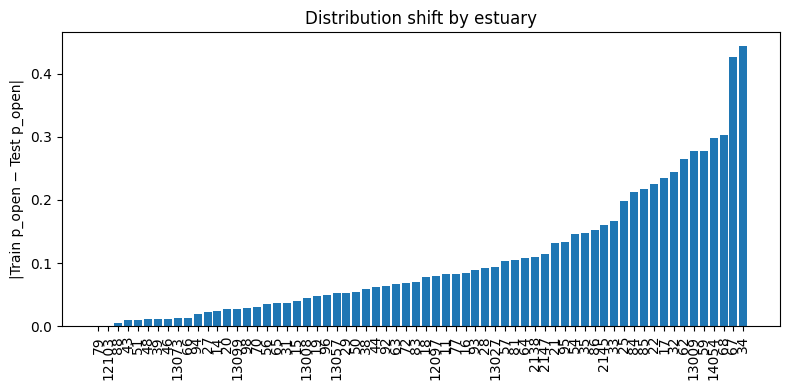

In [196]:
df_sorted = df.sort_values("open_abs_diff")

plt.figure(figsize=(8, 4))

plt.bar(df_sorted.index.astype(str), df_sorted["open_abs_diff"])

plt.xticks(rotation=90)

plt.ylabel("|Train p_open − Test p_open|")
plt.title("Distribution shift by estuary")

plt.tight_layout()
plt.show()

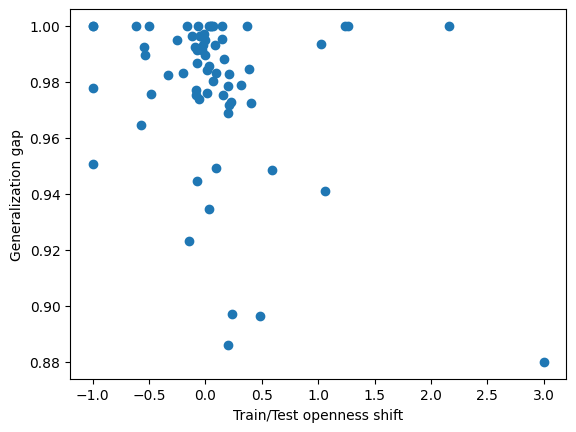

In [215]:
analysis = base_f1.to_frame().merge(df, on="region")

plt.scatter(analysis["open_pct_change"].clip(-3, 3), analysis["f1"].clip(0.88, 1.0))

plt.xlabel("Train/Test openness shift")
plt.ylabel("Generalization gap")

plt.show()

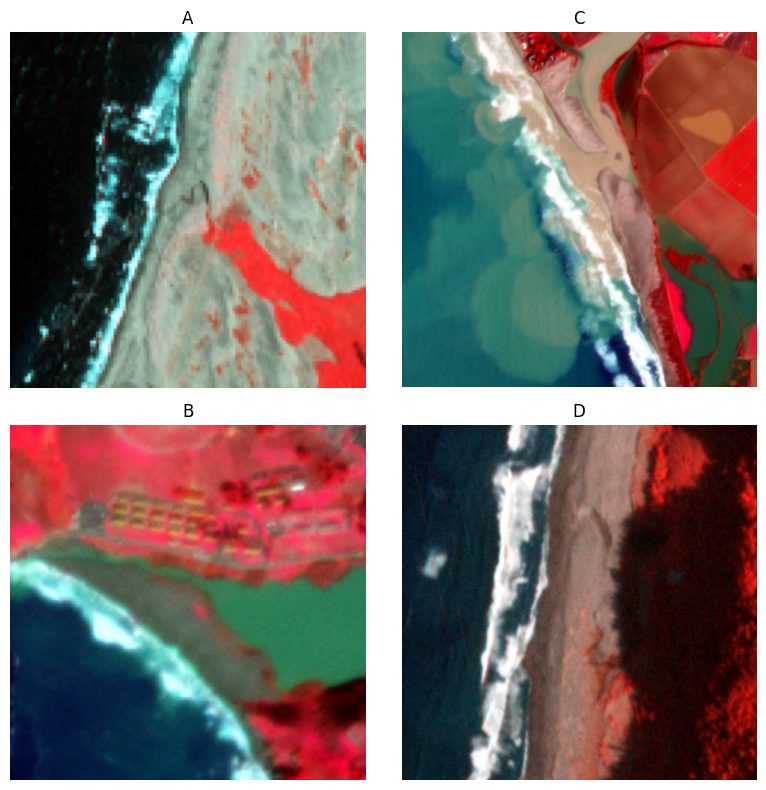

In [231]:
A = "/Users/kyledorman/data/estuary/dataset/images/dove/results/2019/7/13009/files/20190701_173312_1048_3B_AnalyticMS_SR_clip.tif"
B = "/Users/kyledorman/data/estuary/dataset/images/superdove/results/2025/2/2147/files/20250205_191554_60_24f2_3B_AnalyticMS_SR_8b_clip.tif"
C = "/Users/kyledorman/data/estuary/dataset/images/superdove/results/2024/2/51/files/20240206_180833_10_24a1_3B_AnalyticMS_SR_8b_clip.tif"
D = "/Users/kyledorman/data/estuary/dataset/images/dove/results/2021/4/12097/files/20210401_154810_1049_3B_AnalyticMS_SR_clip.tif"

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(8, 8))

axes[0, 0].set_title("A")
axes[0, 0].axis("off")
with rasterio.open(A) as src:
    data = src.read().astype(np.float32)
    nodata = src.read(1, masked=True).mask
    img = false_color(data, nodata)
    import cv2

    img = cv2.resize(img, (120, 120), interpolation=cv2.INTER_CUBIC)
axes[0, 0].imshow(img)

axes[1, 0].set_title("B")
axes[1, 0].axis("off")
with rasterio.open(B) as src:
    data = src.read().astype(np.float32)
    nodata = src.read(1, masked=True).mask
    img = false_color(data, nodata)
axes[1, 0].imshow(img)

axes[0, 1].set_title("C")
axes[0, 1].axis("off")
with rasterio.open(C) as src:
    data = src.read().astype(np.float32)
    nodata = src.read(1, masked=True).mask
    img = false_color(data, nodata)
axes[0, 1].imshow(img)

axes[1, 1].set_title("D")
axes[1, 1].axis("off")
with rasterio.open(D) as src:
    data = src.read().astype(np.float32)
    nodata = src.read(1, masked=True).mask
    img = false_color(data, nodata)
axes[1, 1].imshow(img)

fig.tight_layout()
fig.savefig(SAVE_DIR / "model_challenges.png", dpi=300)
plt.show()